In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('customer_booking.csv', encoding='ISO-8859-1')

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

In [6]:
categorical_cols = ['sales_channel', 'trip_type', 'flight_day', 'route', 'booking_origin']

for col in categorical_cols:
    df[col] = df[col].astype('category').cat.codes

X = df.drop(columns=['booking_complete'])
y = df['booking_complete']

print("Features (X) ready for modeling:")
print(X.head())

Features (X) ready for modeling:
   num_passengers  sales_channel  trip_type  purchase_lead  length_of_stay  \
0               2              0          2            262              19   
1               1              0          2            112              20   
2               2              0          2            243              22   
3               1              0          2             96              31   
4               2              0          2             68              22   

   flight_hour  flight_day  route  booking_origin  wants_extra_baggage  \
0            7           2      0              61                    1   
1            3           2      0              61                    0   
2           17           6      0              36                    1   
3            4           2      0              61                    0   
4           15           6      0              36                    1   

   wants_preferred_seat  wants_in_flight_meals  fligh

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Spliting data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instantiating and train the model
# n_estimators=100 means we are building 100 decision trees
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Generating predictions on the unseen test data
y_pred = model.predict(X_test)

# Evaluating basic accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 85.62%


/tmp/ipykernel_1353/875374459.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_imp[:10], y=feature_imp.index[:10], palette="viridis")


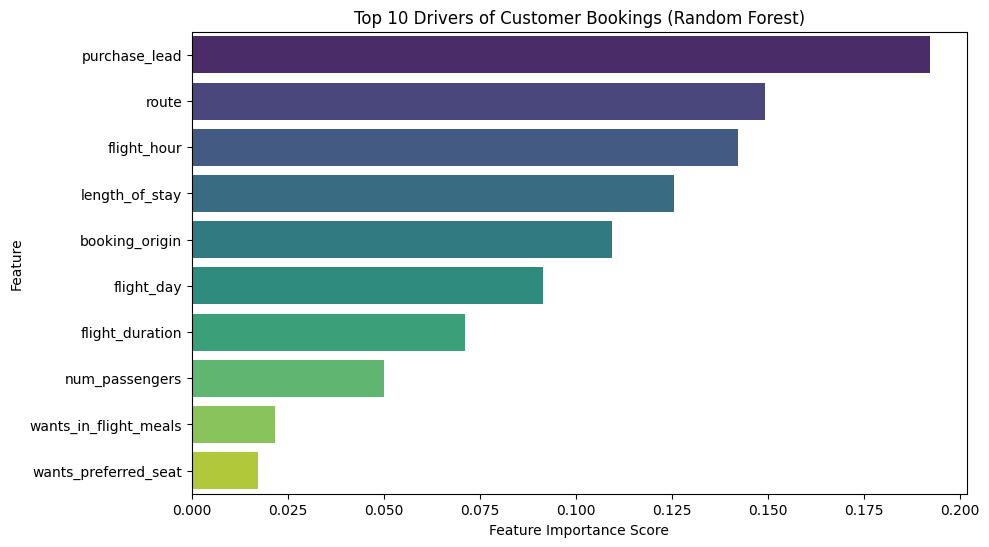

In [8]:
# Extracting feature importance array
importances = model.feature_importances_

# Creating a Pandas Series mapping feature names to their importance score
feature_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

# Ploting the top 10 drivers of customer bookings
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_imp[:10], y=feature_imp.index[:10], palette="viridis")
plt.title('Top 10 Drivers of Customer Bookings (Random Forest)')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.show()